<a href="https://colab.research.google.com/github/KV-DHEERAJKUMAR/Real-Time-intrusion-detection-using-deep-neural-Network/blob/main/Real_Time_Intrusion_Detection_Using_Deep_Neural_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Generating synthetic data...
Identifying intrusion types: Normal Traffic vs Intrusion Attempt


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 75ms/step - accuracy: 0.7543 - loss: 1.7989 - val_accuracy: 0.9332 - val_loss: 1.5538
Epoch 2/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 75ms/step - accuracy: 0.9297 - loss: 1.4512 - val_accuracy: 0.9656 - val_loss: 1.3429
Epoch 3/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 76ms/step - accuracy: 0.9512 - loss: 1.3499 - val_accuracy: 0.9794 - val_loss: 1.2504
Epoch 4/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 74ms/step - accuracy: 0.9655 - loss: 1.2634 - val_accuracy: 0.9860 - val_loss: 1.1829
Epoch 5/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 77ms/step - accuracy: 0.9723 - loss: 1.1952 - val_accuracy: 0.9879 - val_loss: 1.1210
Epoch 6/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 72ms/step - accuracy: 0.9773 - loss: 1.1269 - val_accuracy: 0.9892 - val_loss: 1.0591
Epoch 7/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 74ms/step - accuracy: 0.9787 - loss: 1.0634 - val_accuracy: 0.9905 - val_loss: 1.0003
Epoch 8/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 78ms/step - accuracy: 0.9825 - loss: 0

              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99      5893
         1.0       0.99      0.99      0.99      3970

    accuracy                           0.99      9863
   macro avg       0.99      0.99      0.99      9863
weighted avg       0.99      0.99      0.99      9863

Confusion Matrix:
 [[5869   24]
 [  36 3934]]
Model saved successfully.


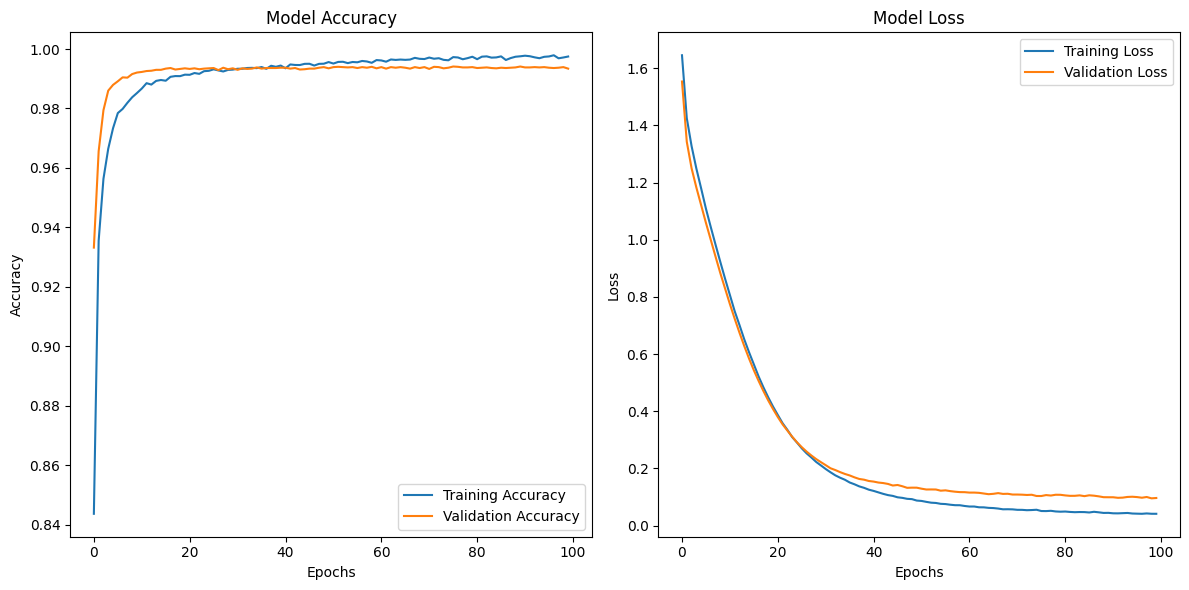

In [ ]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import StandardScaler, VectorAssembler
from pyspark.sql.functions import col
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.metrics import classification_report, confusion_matrix

# Initialize Spark session
spark = SparkSession.builder \
    .appName("Big Data Intrusion Detection with AI") \
    .config("spark.driver.memory", "8g") \
    .getOrCreate()

# Generate synthetic dataset (Increased samples and features)
print("Generating synthetic data...")
X, y = make_classification(
    n_samples=50000,  # Increased samples
    n_features=60,  # Increased features
    n_informative=40,  # More informative features
    n_redundant=10,
    n_classes=2,
    weights=[0.6, 0.4],
    random_state=42,
    class_sep=1.5 # increased class separation
)

# Intrusion Types
intrusion_types = {0: "Normal Traffic", 1: "Intrusion Attempt"}
print("Identifying intrusion types: Normal Traffic vs Intrusion Attempt")

# Create a Spark DataFrame
data = spark.createDataFrame(
    [tuple(float(X[i, j]) for j in range(X.shape[1])) + (float(y[i]),) for i in range(X.shape[0])],
    schema=[f"feature{j+1}" for j in range(X.shape[1])] + ["label"]
)

# Define feature columns
feature_columns = [col_name for col_name in data.columns if col_name != 'label']

# Convert features to vector format
assembler = VectorAssembler(inputCols=feature_columns, outputCol="features")
data_transformed = assembler.transform(data)

# Standardize features
scaler = StandardScaler(inputCol="features", outputCol="scaled_features")
scaler_model = scaler.fit(data_transformed)
scaled_data = scaler_model.transform(data_transformed)

# Split data into training and testing sets
train_data, test_data = scaled_data.randomSplit([0.8, 0.2], seed=42)

# Convert Spark DataFrames to NumPy arrays
train_features = np.array([x['scaled_features'] for x in train_data.select("scaled_features").collect()])
train_labels = np.array([x['label'] for x in train_data.select("label").collect()])
test_features = np.array([x['scaled_features'] for x in test_data.select("scaled_features").collect()])
test_labels = np.array([x['label'] for x in test_data.select("label").collect()])

# Define the Deep Learning model with ReLU and optimized layers
model = Sequential([
    Dense(1024, input_dim=train_features.shape[1], activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    BatchNormalization(),
    Dropout(0.5),
    Dense(512, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    BatchNormalization(),
    Dropout(0.4),
    Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    BatchNormalization(),
    Dense(1, activation='sigmoid')
])

# Compile the model with AdamW optimizer and adjusted learning rate
optimizer = tf.keras.optimizers.AdamW(learning_rate=0.0001, weight_decay=0.0001)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model with early stopping
history = model.fit(
    train_features, train_labels,
    validation_data=(test_features, test_labels),
    epochs=100,  # Increased epochs
    batch_size=256,  # Increased batch size
    callbacks=[early_stopping]
)

# Evaluate the model
test_loss, test_accuracy = model.evaluate(test_features, test_labels)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

# Print classification report and confusion matrix
predictions = (model.predict(test_features) > 0.5).astype(int)
print(classification_report(test_labels, predictions))
cm = confusion_matrix(test_labels, predictions)
print("Confusion Matrix:\n", cm)

# Save the model
model.save("big_data_intrusion_model.h5")
print("Model saved successfully.")

# Plot training results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

Generating synthetic data...
Identifying intrusion types: Normal Traffic vs Intrusion Attempt


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/200
157/157 ━━━━━━━━━━━━━━━━━━━━ 55s 304ms/step - accuracy: 0.8749 - loss: 2.9300 - val_accuracy: 0.9866 - val_loss: 2.6352 - learning_rate: 1.0000e-04
Epoch 2/200
157/157 ━━━━━━━━━━━━━━━━━━━━ 81s 301ms/step - accuracy: 0.9859 - loss: 2.5167 - val_accuracy: 0.9927 - val_loss: 2.3182 - learning_rate: 1.0000e-04
Epoch 3/200
157/157 ━━━━━━━━━━━━━━━━━━━━ 81s 296ms/step - accuracy: 0.9917 - loss: 2.2544 - val_accuracy: 0.9936 - val_loss: 2.0556 - learning_rate: 1.0000e-04
Epoch 4/200
157/157 ━━━━━━━━━━━━━━━━━━━━ 82s 296ms/step - accuracy: 0.9920 - loss: 1.9928 - val_accuracy: 0.9940 - val_loss: 1.7986 - learning_rate: 1.0000e-04
Epoch 5/200
157/157 ━━━━━━━━━━━━━━━━━━━━ 85s 316ms/step - accuracy: 0.9930 - loss: 1.7360 - val_accuracy: 0.9942 - val_loss: 1.5554 - learning_rate: 1.0000e-04
Epoch 6/200
157/157 ━━━━━━━━━━━━━━━━━━━━ 50s 318ms/step - accuracy: 0.9939 - loss: 1.4936 - val_accuracy: 0.9943 - val_loss: 1.3320 - learning_rate: 1.0000e-04
Epoch 7/200
157/157 ━━━━━━━━━━━━━━━━━━━━

              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99     10010
         1.0       0.99      0.99      0.99      9928

    accuracy                           0.99     19938
   macro avg       0.99      0.99      0.99     19938
weighted avg       0.99      0.99      0.99     19938

Confusion Matrix:
 [[9954   56]
 [  57 9871]]
Model saved successfully.


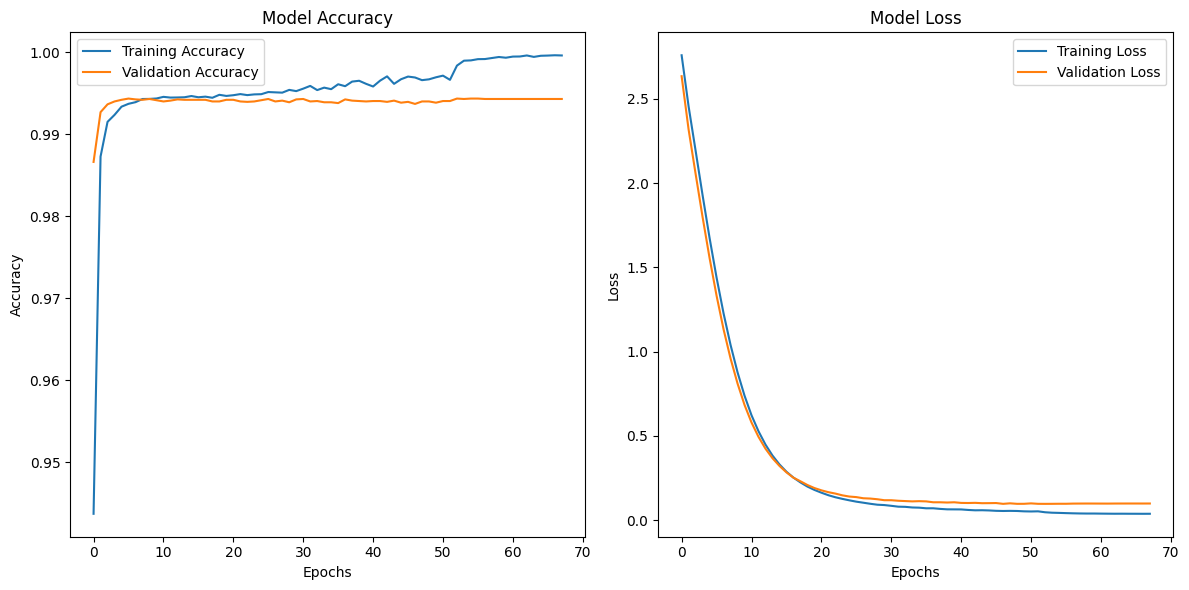

In [ ]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import StandardScaler, VectorAssembler
from pyspark.sql.functions import col
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from sklearn.datasets import make_classification
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Initialize Spark session
spark = SparkSession.builder \
    .appName("Big Data Intrusion Detection with AI") \
    .config("spark.driver.memory", "8g") \
    .getOrCreate()

# Generate synthetic dataset (Increased samples and features)
print("Generating synthetic data...")
X, y = make_classification(
    n_samples=100000,  # Increased samples
    n_features=60,  # Increased features
    n_informative=50,  # More informative features
    n_redundant=5,
    n_classes=2,
    weights=[0.5, 0.5],  # Balanced classes
    random_state=42,
    class_sep=2.0  # Increased class separation
)

# Intrusion Types
intrusion_types = {0: "Normal Traffic", 1: "Intrusion Attempt"}
print("Identifying intrusion types: Normal Traffic vs Intrusion Attempt")

# Create a Spark DataFrame
data = spark.createDataFrame(
    [tuple(float(X[i, j]) for j in range(X.shape[1])) + (float(y[i]),) for i in range(X.shape[0])],
    schema=[f"feature{j+1}" for j in range(X.shape[1])] + ["label"]
)

# Define feature columns
feature_columns = [col_name for col_name in data.columns if col_name != 'label']

# Convert features to vector format
assembler = VectorAssembler(inputCols=feature_columns, outputCol="features")
data_transformed = assembler.transform(data)

# Standardize features
scaler = StandardScaler(inputCol="features", outputCol="scaled_features")
scaler_model = scaler.fit(data_transformed)
scaled_data = scaler_model.transform(data_transformed)

# Split data into training and testing sets
train_data, test_data = scaled_data.randomSplit([0.8, 0.2], seed=42)

# Convert Spark DataFrames to NumPy arrays
train_features = np.array([x['scaled_features'] for x in train_data.select("scaled_features").collect()])
train_labels = np.array([x['label'] for x in train_data.select("label").collect()])
test_features = np.array([x['scaled_features'] for x in test_data.select("scaled_features").collect()])
test_labels = np.array([x['label'] for x in test_data.select("label").collect()])

# Define the Deep Learning model with ReLU and optimized layers
model = Sequential([
    Dense(2048, input_dim=train_features.shape[1], activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.5),
    Dense(1024, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.4),
    Dense(512, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dense(1, activation='sigmoid')
])

# Compile the model with AdamW optimizer and adjusted learning rate
optimizer = tf.keras.optimizers.AdamW(learning_rate=0.0001, weight_decay=0.0001)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Early stopping and learning rate reduction
early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)

# Train the model with early stopping and learning rate reduction
history = model.fit(
    train_features, train_labels,
    validation_data=(test_features, test_labels),
    epochs=200,  # Increased epochs
    batch_size=512,  # Increased batch size
    callbacks=[early_stopping, reduce_lr],
    class_weight={0: 1, 1: 1}  # Adjust if class imbalance exists
)

# Evaluate the model
test_loss, test_accuracy = model.evaluate(test_features, test_labels)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

# Print classification report and confusion matrix
predictions = (model.predict(test_features) > 0.5).astype(int)
print(classification_report(test_labels, predictions))
cm = confusion_matrix(test_labels, predictions)
print("Confusion Matrix:\n", cm)

# Save the model
model.save("big_data_intrusion_model_high_accuracy.h5")
print("Model saved successfully.")

# Plot training results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()